# 🎨 AI Productivity Gains in different Situations
**Source:** [Does AI Actually Boost Developer Productivity? (Stanford 100k Devs Study)](https://www.youtube.com/watch?v=tbDDYKRFjhk)

This notebook uses data from a Stanford study for adding some additional insights on where you can gain productivity using AI.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. GLOBAL STYLE SETTINGS
# Use 'poster' context for large, readable fonts. Use 'white' style for a clean look.
sns.set_theme(style="white", context="poster")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Helper to format ranges nicely
def fmt_range(r):
    return f"{'+' if r[0] >= 0 else ''}{r[0]}–{r[1]}%"

## 1. Project Maturity: The "Legacy Drag" Effect
Rebuild the first relevant chart from the talk about in which scenarios AI can help developers.

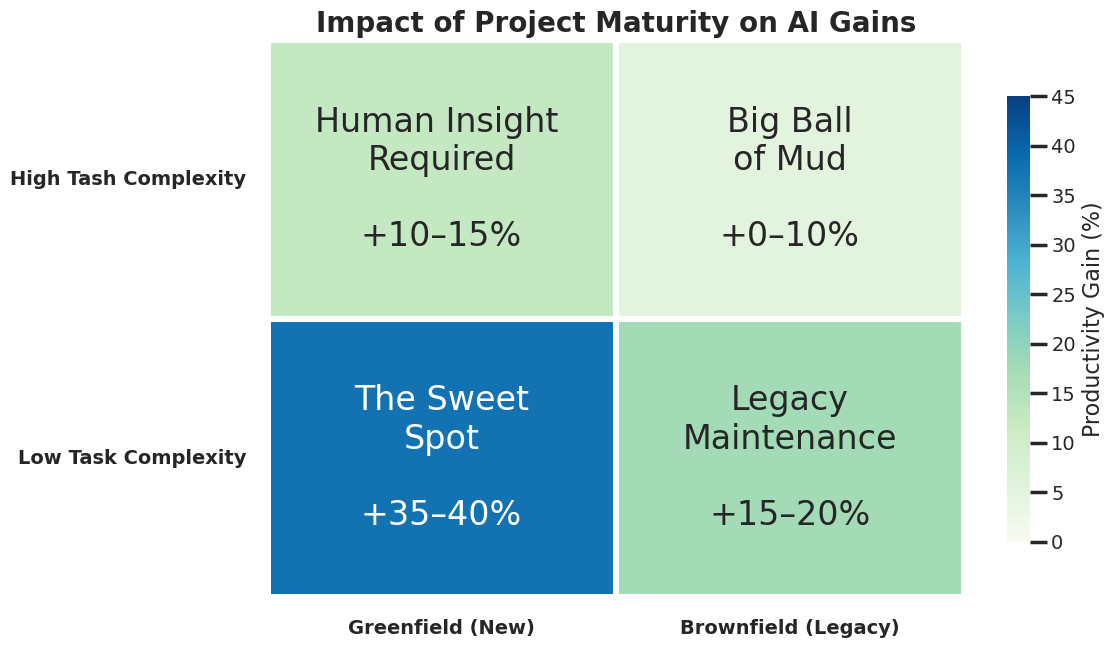

In [2]:
# Data Intervals
g_high, g_low = [10, 15], [35, 40]
b_high, b_low = [0, 10],  [15, 20]

# Matrix & Labels
maturity_data = np.array([[np.mean(g_high), np.mean(b_high)], 
                          [np.mean(g_low),  np.mean(b_low)]])

labels = np.array([
    [f"Human Insight \nRequired\n\n{fmt_range(g_high)}", f"Big Ball\nof Mud\n\n{fmt_range(b_high)}"],
    [f"The Sweet\nSpot\n\n{fmt_range(g_low)}",         f"Legacy\nMaintenance\n\n{fmt_range(b_low)}"]
])

# Plotting
plt.figure(figsize=(12, 7))
ax = sns.heatmap(maturity_data, annot=labels, fmt="", 
                 cmap="GnBu", vmin=0, vmax=45,  # Fixed scale for consistency
                 linewidths=4, linecolor='white',
                 cbar_kws={'label': 'Productivity Gain (%)', 'shrink': 0.8})

ax.set_xticklabels(['Greenfield (New)', 'Brownfield (Legacy)'], weight='bold')
ax.set_yticklabels(['High Tash Complexity', 'Low Task Complexity'], weight='bold', rotation=0)

plt.title("Impact of Project Maturity on AI Gains", weight='bold')
plt.tight_layout()
plt.show()

### My interpretation

The first chart illustrates that AI productivity gains are maximized in greenfield / new projects with low-complexity tasks, with a 35–40% increase. The reason is simple: todo lists are simple to implement and the amount of code is tiny. However, these gains diminish significantly as project maturity increases or complexity rises. Brownfield / legacy projects see gains drop to 15–20% for simple maintenance tasks, while high-complexity legacy tasks in systems that are already a Big Ball of Mud yield only 0–10% productivity gains. But even in ideal greenfield environments, high-complexity work limits AI's impact to just 10–15%, because such tasks still heavily rely on human insight rather than mechanical automation.


## 2. Language Popularity: The "Niche Penalty"
Rebuild the second chart that studies the impact of the used programming language.

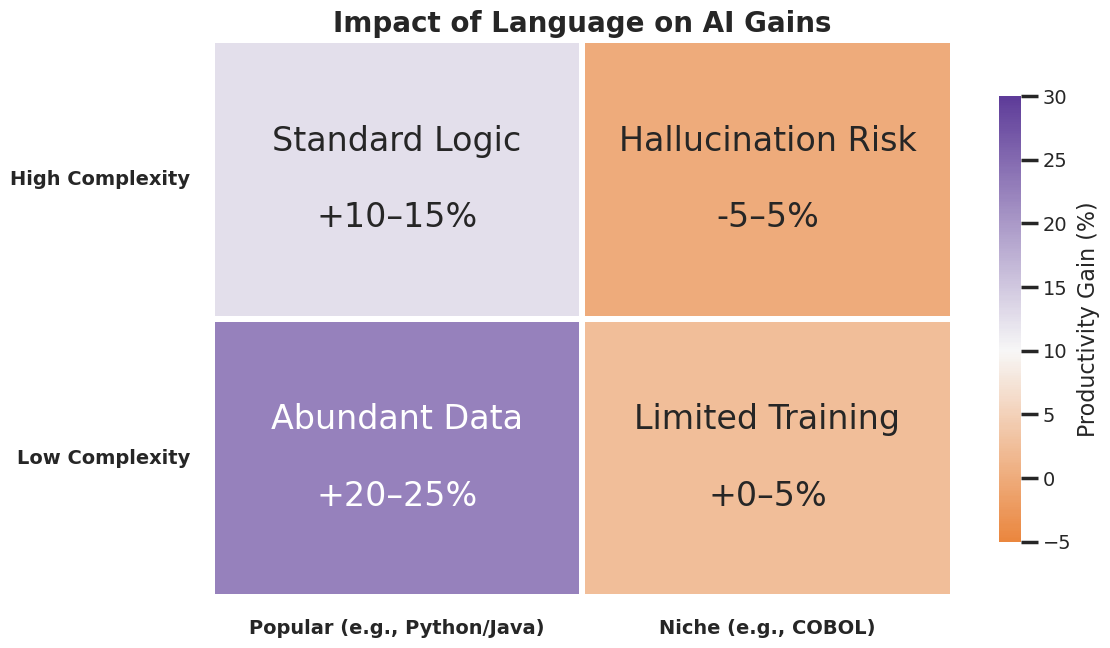

In [3]:
# Data Intervals
p_high, p_low = [10, 15], [20, 25]
n_high, n_low = [-5, 5],  [0, 5]

lang_data = np.array([[np.mean(p_high), np.mean(n_high)], 
                      [np.mean(p_low),  np.mean(n_low)]])

labels = np.array([
    [f"Standard Logic\n\n{fmt_range(p_high)}",   f"Hallucination Risk\n\n{fmt_range(n_high)}"],
    [f"Abundant Data\n\n{fmt_range(p_low)}",     f"Limited Training\n\n{fmt_range(n_low)}"]
])

plt.figure(figsize=(12, 7))
# Custom Colormap: Orange (Bad) -> White -> Purple (Good)
cmap = LinearSegmentedColormap.from_list("custom_div", ["#e66101", "#f7f7f7", "#5e3c99"])

ax = sns.heatmap(lang_data, annot=labels, fmt="", 
                 cmap=cmap, center=10, vmin=-5, vmax=30,
                 linewidths=4, linecolor='white',
                 cbar_kws={'label': 'Productivity Gain (%)', 'shrink': 0.8})

ax.set_xticklabels(['Popular (e.g., Python/Java)', 'Niche (e.g., COBOL)'], weight='bold')
ax.set_yticklabels(['High Complexity', 'Low Complexity'], weight='bold', rotation=0)

plt.title("Impact of Language on AI Gains", weight='bold')
plt.tight_layout()
plt.show()

### My interpretation

In popular languages (e.g., Python, Java), AI delivers its highest value, boosting productivity by 20–25% on simple tasks due to abundant training data (e.g., due to Reinforcement Learning where you have thousands of simple question and answer pairs) and 10–15% on complex ones, where it can apply the standard logic of a programming language based on diverse training data. Conversely, niche languages (e.g., COBOL) see negligible gains of 0–5% for simple work due to limited training data, and for high-complexity tasks they enter an area with a higher risk of hallucinations, where productivity can actually drop to -5%. This illustrates that without sufficient training data, AI tools can become a liability rather than an asset for complex engineering work.

## 3. The Combined Story: "Heaven" vs. "Hell"
This chart combines the means of the productivity gains from the previous two charts to create a third view, based on language popularity and project type. For each quadrant, the midpoints of both complexity levels are averaged together, giving equal weight to low and high complexity tasks.

*Note: This combined view is not a formally validated model but rather a pragmatic approximation, blending two independent data sources through simple averaging. It is intended to provide directional insight rather than precise predictions.*

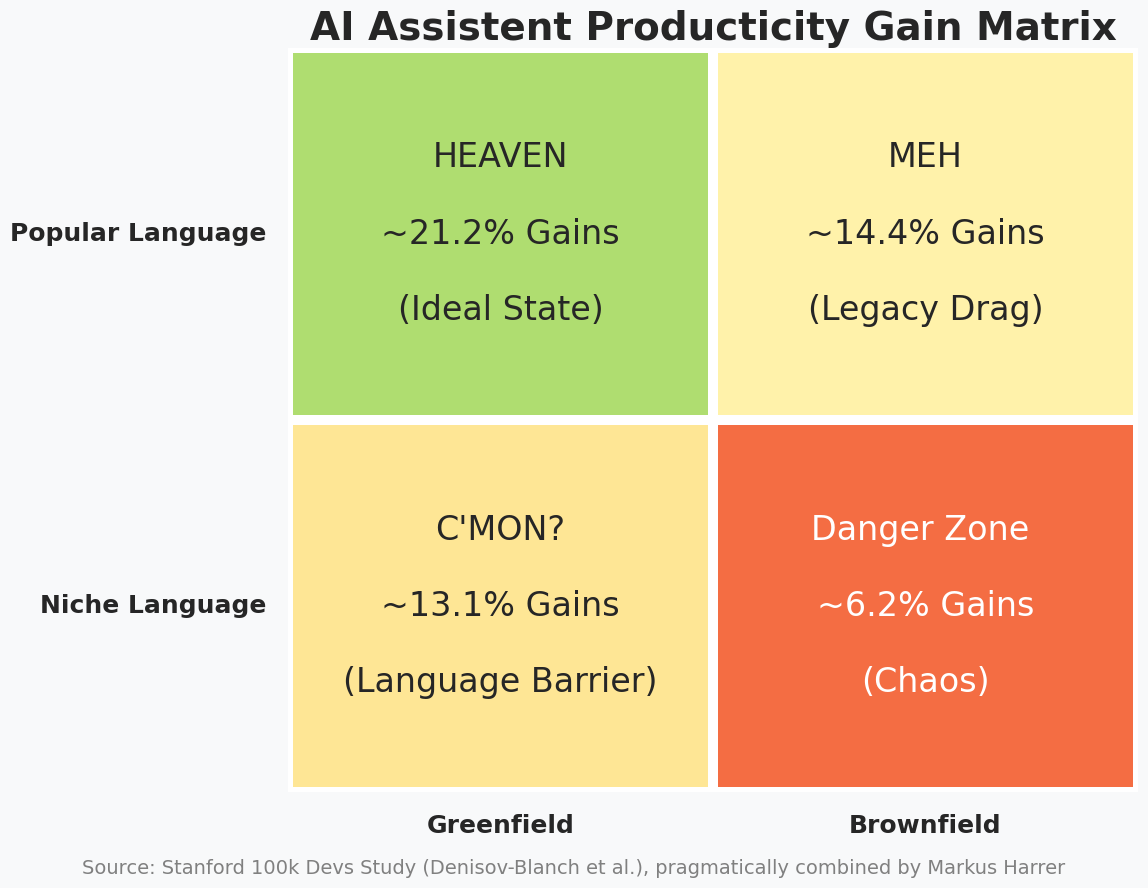

In [4]:
# Calculate Combined Midpoints
def calc_mean(m, l): return (np.mean(m) + np.mean(l)) / 2

heaven = (calc_mean(g_low, p_low) + calc_mean(g_high, p_high)) / 2
meh    = (calc_mean(b_low, p_low) + calc_mean(b_high, p_high)) / 2
cmon   = (calc_mean(g_low, n_low) + calc_mean(g_high, n_high)) / 2
danger    = (calc_mean(b_low, n_low) + calc_mean(b_high, n_high)) / 2

mean_data = np.array([[heaven, meh], [cmon, danger]])

# Detailed Storytelling Labels
mean_labels = np.array([
    [f"HEAVEN\n\n~{heaven:.1f}% Gains\n\n(Ideal State)",  f"MEH\n\n~{meh:.1f}% Gains\n\n(Legacy Drag)"],
    [f"C'MON?\n\n~{cmon:.1f}% Gains\n\n(Language Barrier)", f"Danger Zone \n\n~{danger:.1f}% Gains\n\n(Chaos)"]
])

plt.figure(figsize=(12, 9))

# RdYlGn is perfect here: Red (Danger) -> Green (Heaven)
ax = sns.heatmap(mean_data, annot=mean_labels, fmt="", 
                 cmap="RdYlGn", vmin=0, vmax=max([heaven,meh,cmon,danger])+10,
                 linewidths=6, linecolor='white',
                 cbar=False) # No colorbar needed, labels tell the story

ax.set_xticklabels(['Greenfield', 'Brownfield'], weight='bold', fontsize=18)
ax.set_yticklabels(['Popular Language', 'Niche Language'], weight='bold', fontsize=18, rotation=0)

# Add a subtle background color to the figure for polish
plt.gcf().set_facecolor('#f8f9fa')

plt.title("AI Assistent Producticity Gain Matrix", fontsize=28, weight='heavy')
plt.figtext(0.5, 0, "Source: Stanford 100k Devs Study (Denisov-Blanch et al.), pragmatically combined by Markus Harrer", 
            ha="center", fontsize=14, color="gray")


plt.tight_layout()
plt.show()

### My interpretation

When combining both dimensions, project maturity (greenfield vs. brownfield) and programming language popularity, a clear productivity matrix emerges. The best-case scenario, labelled "Heaven," occurs when working in a popular language on a greenfield project, yielding ~21.2% productivity gains. This is the ideal state: abundant training data meets a clean, unencumbered codebase, allowing AI to operate at full effectiveness.
Moving to brownfield projects in popular languages ("Meh"), gains drop to ~14.4% due to legacy drag. The AI still understands the language well, but the complexity and technical debt of the existing codebase limits how much it can contribute.

Interestingly, niche languages on greenfield projects ("C'mon?") still yield ~13.1% gains, slightly lower than the brownfield popular language scenario, suggesting that a clean codebase can partially compensate for weaker training data, but the language barrier remains a meaningful ceiling.
The worst-case scenario is "Danger Zone": a niche language combined with a brownfield codebase, producing only ~6.2% gains. Here, both obstacles compound each other. The AI lacks sufficient training data for the language and simultaneously struggles to reason about a tangled, legacy codebase, resulting in chaos and a high risk of unreliable outputs.

The key takeaway is that language popularity and project maturity are both independently significant, but their combined effect is multiplicative rather than merely additive. Teams working in niche languages on legacy systems should be especially cautious about over-relying on AI tooling.